# Supermarket Sales Performance & Customer Analytics

## Professional Data Analytics Project

**Dataset:** `SUPER MARKET DATA.xlsx`

This notebook performs an end-to-end retail analytics workflow:

1. Data loading and profiling
2. Data quality checks
3. Data cleaning and validation
4. Feature engineering
5. KPI analysis
6. Branch and city analysis
7. Product and category analysis
8. Customer analysis
9. Gender and payment analysis
10. Time-series analysis
11. Customer satisfaction analysis
12. Correlation analysis
13. Outlier analysis
14. Statistical testing
15. Cross-segment analysis
16. Business insights
17. Recommendations
18. Dashboard-ready datasets and visualizations

> **Important:** The dataset contains sales data but does not contain costs, expenses, or profit. Therefore, this notebook does not claim profitability.


## 1. Install / Import Required Libraries

In [38]:
# If running in Google Colab and packages are missing, uncomment:
# !pip install pandas openpyxl numpy matplotlib seaborn scipy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from pathlib import Path
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Excel Dataset

### Google Colab
Upload `SUPER MARKET DATA.xlsx` using the file-upload cell below.

### Jupyter Notebook
Place the Excel file in the same folder as this notebook.


In [2]:
# ---------- Google Colab ----------
# Uncomment the following two lines when using Google Colab:
# from google.colab import files
# uploaded = files.upload()

# ---------- File path ----------
FILE_PATH = "/content/SUPER MARKET DATA.xlsx"

# For local Jupyter, this should work when the Excel file is beside the notebook.
# If necessary, replace FILE_PATH with the full path to your file.

df_raw = pd.read_excel(FILE_PATH)

print(f"Dataset loaded successfully: {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} columns")
display(df_raw.head())


Dataset loaded successfully: 500 rows × 13 columns


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.80,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.90,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.40,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.50,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.10,652.85


## 3. Initial Dataset Profile

In [3]:
print("Shape:", df_raw.shape)
print("\nColumns:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i}. {col}")

print("\nData types:")
display(df_raw.dtypes.to_frame("Data Type"))

print("\nDescriptive statistics:")
display(df_raw.describe(include="all").T)


Shape: (500, 13)

Columns:
1. Invoice ID
2. Date
3. Branch
4. City
5. Customer Type
6. Gender
7. Product
8. Category
9. Quantity
10. Unit Price
11. Payment
12. Rating
13. Sales

Data types:


,Data Type
Invoice ID,object
Date,datetime64[ns]
Branch,object
City,object
Customer Type,object
Gender,object
Product,object
Category,object
Quantity,int64
Unit Price,float64



Descriptive statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice ID,500,500,INV0500,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,500,NaN,NaN,NaN,2026-04-03 12:25:55.199999744,2026-01-01 00:00:00,2026-02-17 00:00:00,2026-04-09 00:00:00,2026-05-17 06:00:00,2026-07-01 00:00:00,NaN
Branch,500,4,C,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,500,4,Mumbai,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,500,2,Member,296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,500,2,Female,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,500,20,Rice,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,500,8,Grocery,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,500.00,NaN,NaN,NaN,5.54,1.00,3.00,5.50,8.00,10.00,2.88
Unit Price,500.00,NaN,NaN,NaN,88.66,27.67,43.95,61.88,128.57,236.71,57.28


## 4. Data Quality Assessment

In [4]:
quality = pd.DataFrame({
    "Column": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
    "Missing Values": df_raw.isna().sum().values,
    "Missing %": (df_raw.isna().mean() * 100).values,
    "Unique Values": df_raw.nunique(dropna=True).values
})

display(quality)

print("Duplicate rows:", df_raw.duplicated().sum())

# Duplicate Invoice IDs
if "Invoice ID" in df_raw.columns:
    print("Duplicate Invoice IDs:", df_raw["Invoice ID"].duplicated().sum())


,Column,Data Type,Missing Values,Missing %,Unique Values
0,Invoice ID,object,0,0.00,500
1,Date,datetime64[ns],0,0.00,173
2,Branch,object,0,0.00,4
3,City,object,0,0.00,4
4,Customer Type,object,0,0.00,2
5,Gender,object,0,0.00,2
6,Product,object,0,0.00,20
7,Category,object,0,0.00,8
8,Quantity,int64,0,0.00,10
9,Unit Price,float64,0,0.00,488


Duplicate rows: 0
Duplicate Invoice IDs: 0


## 5. Clean and Standardize the Dataset

In [5]:
df = df_raw.copy()

# Standardize column names
df.columns = [str(c).strip() for c in df.columns]

# Strip whitespace from text columns
text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Convert date
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Convert expected numeric columns
numeric_cols = ["Quantity", "Unit Price", "Rating", "Sales"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Cleaning completed.")
display(df.head())


Cleaning completed.


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.80,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.90,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.40,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.50,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.10,652.85


## 6. Validate Business Rules

In [6]:
validation = {}

validation["Missing values"] = int(df.isna().sum().sum())
validation["Duplicate rows"] = int(df.duplicated().sum())

if "Quantity" in df:
    validation["Non-positive Quantity"] = int((df["Quantity"] <= 0).sum())

if "Unit Price" in df:
    validation["Non-positive Unit Price"] = int((df["Unit Price"] <= 0).sum())

if "Rating" in df:
    validation["Rating outside 1-5"] = int(((df["Rating"] < 1) | (df["Rating"] > 5)).sum())

if "Sales" in df:
    validation["Non-positive Sales"] = int((df["Sales"] <= 0).sum())

display(pd.Series(validation, name="Count").to_frame())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())


,Count
Missing values,0
Duplicate rows,0
Non-positive Quantity,0
Non-positive Unit Price,0
Rating outside 1-5,0
Non-positive Sales,0



Date range:
2026-01-01 00:00:00 to 2026-07-01 00:00:00


## 7. Verify Sales Calculation

In [7]:
df["Calculated Sales"] = df["Quantity"] * df["Unit Price"]
df["Sales Difference"] = df["Sales"] - df["Calculated Sales"]

sales_check = pd.DataFrame({
    "Metric": [
        "Maximum absolute difference",
        "Mean absolute difference",
        "Rows with difference > 0.01"
    ],
    "Value": [
        df["Sales Difference"].abs().max(),
        df["Sales Difference"].abs().mean(),
        (df["Sales Difference"].abs() > 0.01).sum()
    ]
})

display(sales_check)

# Show any discrepancies
discrepancies = df[df["Sales Difference"].abs() > 0.01]
if len(discrepancies):
    display(discrepancies)
else:
    print("Sales values are consistent with Quantity × Unit Price within the tolerance.")


,Metric,Value
0,Maximum absolute difference,0.00
1,Mean absolute difference,0.00
2,Rows with difference > 0.01,0.00


Sales values are consistent with Quantity × Unit Price within the tolerance.


## 8. Feature Engineering

In [8]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Month Number"] = df["Date"].dt.month
df["Month-Year"] = df["Date"].dt.to_period("M").astype(str)
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)
df["Day of Week"] = df["Date"].dt.day_name()

# Useful retail metrics
df["Sales per Unit"] = df["Sales"] / df["Quantity"]
df["Rating Segment"] = pd.cut(
    df["Rating"],
    bins=[-np.inf, 3, 4, 4.5, np.inf],
    labels=["Low", "Average", "Good", "Excellent"],
    right=False
)

print("Feature engineering completed.")
display(df.head())


Feature engineering completed.


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales,Calculated Sales,Sales Difference,Year,Month,Month Number,Month-Year,Quarter,Day of Week,Sales per Unit,Rating Segment
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.80,228.52,228.52,0.00,2026,June,6,2026-06,2026Q2,Monday,57.13,Average
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.90,601.65,601.65,0.00,2026,February,2,2026-02,2026Q1,Thursday,66.85,Average
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.40,171.84,171.84,0.00,2026,February,2,2026-02,2026Q1,Monday,57.28,Average
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.50,336.54,336.54,0.00,2026,January,1,2026-01,2026Q1,Monday,168.27,Excellent
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.10,652.85,652.85,0.00,2026,June,6,2026-06,2026Q2,Tuesday,130.57,Average


## 9. Executive KPI Analysis

In [9]:
total_sales = df["Sales"].sum()
transactions = len(df)
total_quantity = df["Quantity"].sum()
avg_transaction_value = df["Sales"].mean()
avg_unit_price = df["Unit Price"].mean()
avg_rating = df["Rating"].mean()

kpis = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Transactions",
        "Total Quantity Sold",
        "Average Transaction Value",
        "Average Unit Price",
        "Average Rating",
        "Unique Products",
        "Unique Categories",
        "Unique Branches",
        "Unique Cities"
    ],
    "Value": [
        total_sales,
        transactions,
        total_quantity,
        avg_transaction_value,
        avg_unit_price,
        avg_rating,
        df["Product"].nunique(),
        df["Category"].nunique(),
        df["Branch"].nunique(),
        df["City"].nunique()
    ]
})

display(kpis)


,KPI,Value
0,Total Sales,"244,411.08"
1,Total Transactions,500.00
2,Total Quantity Sold,"2,768.00"
3,Average Transaction Value,488.82
4,Average Unit Price,88.66
5,Average Rating,3.99
6,Unique Products,20.00
7,Unique Categories,8.00
8,Unique Branches,4.00
9,Unique Cities,4.00


## 10. Branch and City Performance

In [10]:
branch_summary = df.groupby(["Branch", "City"]).agg(
    Transactions=("Invoice ID", "count"),
    Sales=("Sales", "sum"),
    Quantity=("Quantity", "sum"),
    Average_Transaction_Value=("Sales", "mean"),
    Average_Rating=("Rating", "mean"),
    Average_Unit_Price=("Unit Price", "mean")
).reset_index()

branch_summary["Sales Share %"] = branch_summary["Sales"] / total_sales * 100
branch_summary = branch_summary.sort_values("Sales", ascending=False)

display(branch_summary)

city_summary = df.groupby("City").agg(
    Transactions=("Invoice ID", "count"),
    Sales=("Sales", "sum"),
    Quantity=("Quantity", "sum"),
    Average_Transaction_Value=("Sales", "mean"),
    Average_Rating=("Rating", "mean")
).reset_index()

city_summary["Sales Share %"] = city_summary["Sales"] / total_sales * 100
city_summary = city_summary.sort_values("Sales", ascending=False)

display(city_summary)


,Branch,City,Transactions,Sales,Quantity,Average_Transaction_Value,Average_Rating,Average_Unit_Price,Sales Share %
2,C,Mumbai,143,"72,469.45",807,506.78,4.05,90.33,29.65
1,B,Delhi,133,"64,116.26",692,482.08,3.98,87.29,26.23
3,D,Bengaluru,119,"55,468.29",669,466.12,4.09,85.64,22.69
0,A,Jaipur,105,"52,357.08",600,498.64,3.84,91.54,21.42


,City,Transactions,Sales,Quantity,Average_Transaction_Value,Average_Rating,Sales Share %
3,Mumbai,143,"72,469.45",807,506.78,4.05,29.65
1,Delhi,133,"64,116.26",692,482.08,3.98,26.23
0,Bengaluru,119,"55,468.29",669,466.12,4.09,22.69
2,Jaipur,105,"52,357.08",600,498.64,3.84,21.42


## 11. Branch / City Sales Visualization

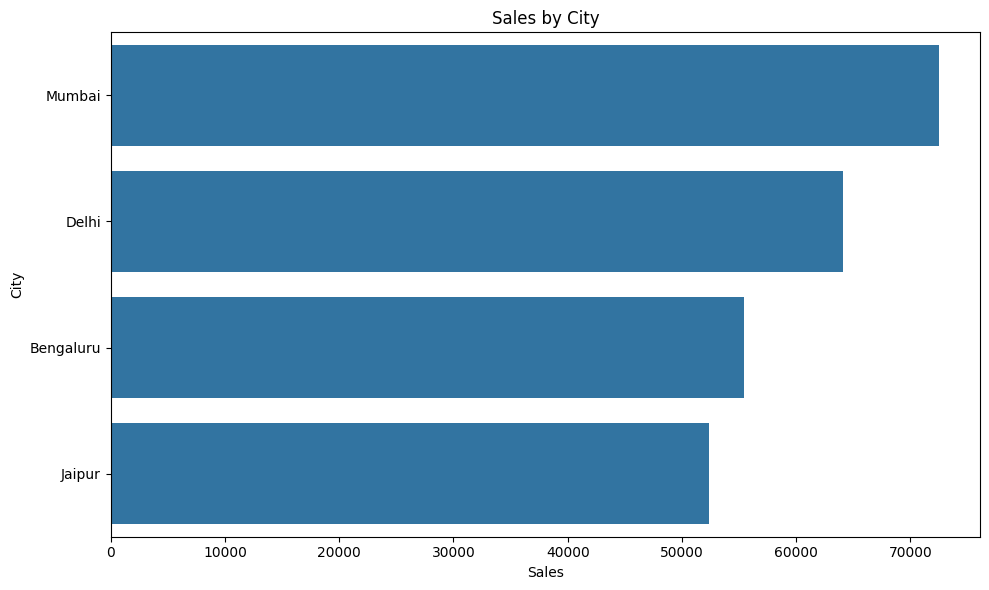

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=city_summary, x="Sales", y="City")
plt.title("Sales by City")
plt.xlabel("Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()


## 12. Product Performance

In [12]:
product_summary = df.groupby("Product").agg(
    Transactions=("Invoice ID", "count"),
    Quantity=("Quantity", "sum"),
    Sales=("Sales", "sum"),
    Average_Unit_Price=("Unit Price", "mean"),
    Average_Transaction_Value=("Sales", "mean"),
    Average_Rating=("Rating", "mean")
).reset_index()

product_summary["Sales Share %"] = product_summary["Sales"] / total_sales * 100
product_summary = product_summary.sort_values("Sales", ascending=False)

print("Top 10 products by sales")
display(product_summary.head(10))

print("Bottom 10 products by sales")
display(product_summary.tail(10).sort_values("Sales"))


Top 10 products by sales


,Product,Transactions,Quantity,Sales,Average_Unit_Price,Average_Transaction_Value,Average_Rating,Sales Share %
4,Cheese,26,126,"27,906.30",221.71,"1,073.32",3.98,11.42
7,Coffee,24,153,"27,694.87",181.01,"1,153.95",3.86,11.33
16,Shampoo,27,152,"27,497.48",179.29,"1,018.43",3.92,11.25
9,Cooking Oil,26,142,"21,525.06",150.55,827.89,3.97,8.81
18,Tea,29,146,"17,681.59",119.87,609.71,4.02,7.23
0,Apples,20,119,"17,057.41",141.85,852.87,3.86,6.98
11,Face Wash,19,100,"11,946.85",119.30,628.78,3.90,4.89
15,Rice,29,167,"11,754.17",70.48,405.32,3.84,4.81
8,Cold Drink,29,166,"10,731.78",65.06,370.06,3.98,4.39
10,Eggs,20,117,"10,429.77",89.16,521.49,4.03,4.27


Bottom 10 products by sales


,Product,Transactions,Quantity,Sales,Average_Unit_Price,Average_Transaction_Value,Average_Rating,Sales Share %
2,Biscuits,26,130,"3,908.87",29.98,150.34,4.03,1.60
19,Tomato,21,96,"4,324.79",45.19,205.94,3.99,1.77
12,Milk,22,102,"5,655.93",55.19,257.09,4.10,2.31
5,Chips,26,168,"5,833.45",34.71,224.36,4.08,2.39
1,Bananas,24,104,"6,205.76",59.84,258.57,3.80,2.54
17,Soap,27,147,"6,499.63",44.60,240.73,4.03,2.66
3,Bread,28,164,"6,516.10",39.90,232.72,4.24,2.67
14,Potato,27,194,"6,799.38",34.99,251.83,3.98,2.78
13,Noodles,27,130,"7,191.24",54.90,266.34,4.02,2.94
6,Chocolate,23,145,"7,250.65",49.70,315.25,4.23,2.97


## 13. Product Sales Visualization

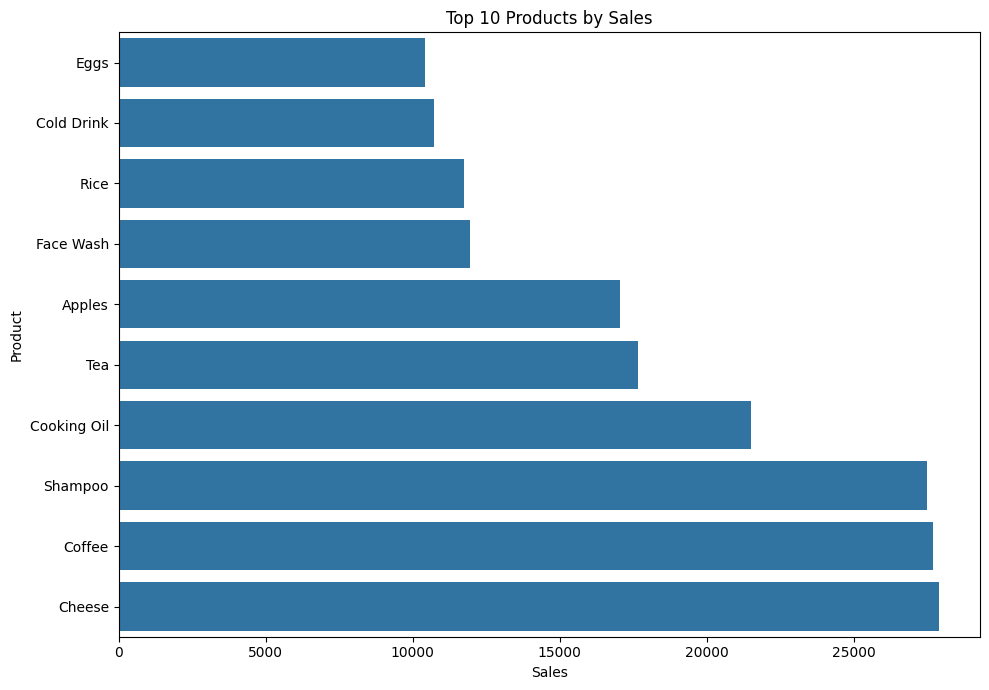

In [13]:
top10_products = product_summary.head(10).sort_values("Sales")

plt.figure(figsize=(10, 7))
sns.barplot(data=top10_products, x="Sales", y="Product")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


## 14. Category Performance

In [14]:
category_summary = df.groupby("Category").agg(
    Transactions=("Invoice ID", "count"),
    Quantity=("Quantity", "sum"),
    Sales=("Sales", "sum"),
    Average_Unit_Price=("Unit Price", "mean"),
    Average_Transaction_Value=("Sales", "mean"),
    Average_Rating=("Rating", "mean")
).reset_index()

category_summary["Sales Share %"] = category_summary["Sales"] / total_sales * 100
category_summary = category_summary.sort_values("Sales", ascending=False)

display(category_summary)


,Category,Transactions,Quantity,Sales,Average_Unit_Price,Average_Transaction_Value,Average_Rating,Sales Share %
1,Beverages,82,465,"56,108.24",118.38,684.25,3.96,22.96
5,Personal Care,73,399,"45,943.96",113.86,629.37,3.95,18.80
2,Dairy,68,345,"43,992.00",128.85,646.94,4.03,18.00
4,Grocery,82,439,"40,470.47",90.74,493.54,3.94,16.56
3,Fruits,44,223,"23,263.17",97.12,528.71,3.83,9.52
6,Snacks,75,443,"16,992.97",37.66,226.57,4.11,6.95
7,Vegetables,48,290,"11,124.17",39.45,231.75,3.99,4.55
0,Bakery,28,164,"6,516.10",39.90,232.72,4.24,2.67


## 15. Category Sales Visualization

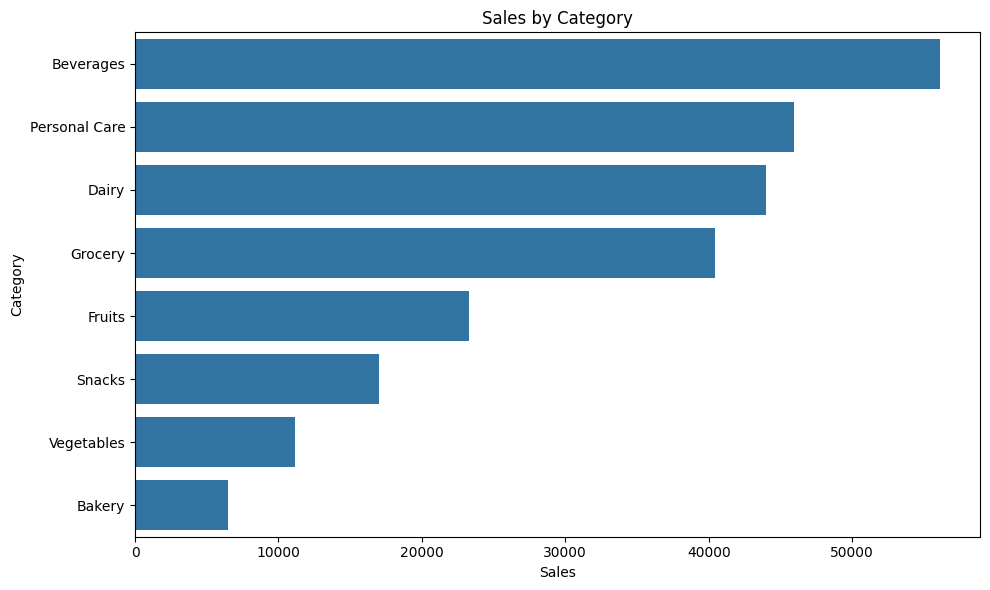

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=category_summary, x="Sales", y="Category")
plt.title("Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


## 16. Customer Type Analysis

In [16]:
customer_summary = df.groupby("Customer Type").agg(
    Transactions=("Invoice ID", "count"),
    Sales=("Sales", "sum"),
    Quantity=("Quantity", "sum"),
    Average_Transaction_Value=("Sales", "mean"),
    Average_Quantity=("Quantity", "mean"),
    Average_Rating=("Rating", "mean")
).reset_index()

customer_summary["Sales Share %"] = customer_summary["Sales"] / total_sales * 100

display(customer_summary)


,Customer Type,Transactions,Sales,Quantity,Average_Transaction_Value,Average_Quantity,Average_Rating,Sales Share %
0,Member,296,"143,009.30",1659,483.14,5.60,4.01,58.51
1,Normal,204,"101,401.78",1109,497.07,5.44,3.97,41.49


## 17. Gender Analysis

In [17]:
gender_summary = df.groupby("Gender").agg(
    Transactions=("Invoice ID", "count"),
    Sales=("Sales", "sum"),
    Quantity=("Quantity", "sum"),
    Average_Transaction_Value=("Sales", "mean"),
    Average_Rating=("Rating", "mean")
).reset_index()

gender_summary["Sales Share %"] = gender_summary["Sales"] / total_sales * 100

display(gender_summary)


,Gender,Transactions,Sales,Quantity,Average_Transaction_Value,Average_Rating,Sales Share %
0,Female,255,"123,954.12",1380,486.09,4.01,50.72
1,Male,245,"120,456.96",1388,491.66,3.98,49.28


## 18. Payment Method Analysis

In [18]:
payment_summary = df.groupby("Payment").agg(
    Transactions=("Invoice ID", "count"),
    Sales=("Sales", "sum"),
    Quantity=("Quantity", "sum"),
    Average_Transaction_Value=("Sales", "mean"),
    Average_Rating=("Rating", "mean")
).reset_index()

payment_summary["Sales Share %"] = payment_summary["Sales"] / total_sales * 100
payment_summary = payment_summary.sort_values("Sales", ascending=False)

display(payment_summary)


,Payment,Transactions,Sales,Quantity,Average_Transaction_Value,Average_Rating,Sales Share %
3,UPI,127,"67,910.33",705,534.73,4.02,27.79
2,Net Banking,126,"65,194.93",749,517.42,3.95,26.67
0,Card,125,"57,265.64",665,458.13,3.98,23.43
1,Cash,122,"54,040.18",649,442.95,4.03,22.11


## 19. Payment Method Visualization

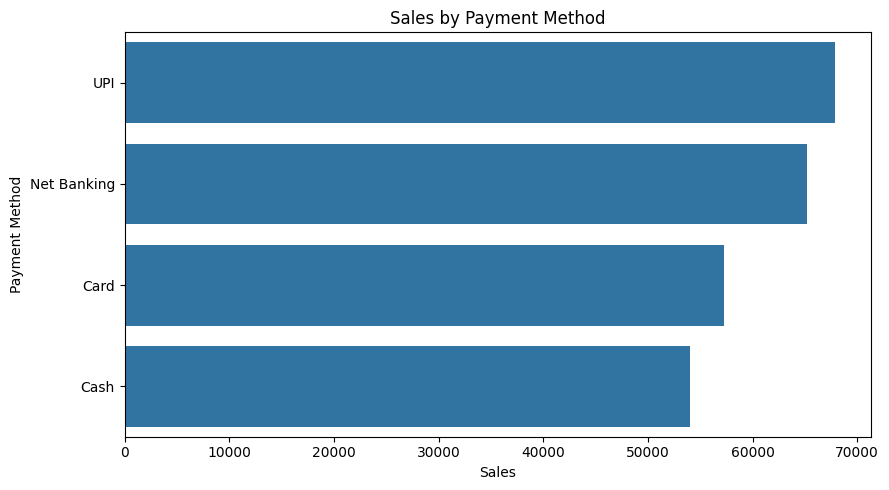

In [19]:
plt.figure(figsize=(9, 5))
sns.barplot(data=payment_summary, x="Sales", y="Payment")
plt.title("Sales by Payment Method")
plt.xlabel("Sales")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()


## 20. Monthly Time-Series Analysis

In [20]:
monthly_summary = df.groupby(["Year", "Month Number", "Month"]).agg(
    Transactions=("Invoice ID", "count"),
    Sales=("Sales", "sum"),
    Quantity=("Quantity", "sum"),
    Average_Transaction_Value=("Sales", "mean"),
    Average_Rating=("Rating", "mean")
).reset_index()

monthly_summary = monthly_summary.sort_values(["Year", "Month Number"])
monthly_summary["Sales MoM %"] = monthly_summary["Sales"].pct_change() * 100

display(monthly_summary)


,Year,Month Number,Month,Transactions,Sales,Quantity,Average_Transaction_Value,Average_Rating,Sales MoM %
0,2026,1,January,88,"43,415.53",456,493.36,3.95,NaN
1,2026,2,February,65,"30,068.15",376,462.59,4.06,-30.74
2,2026,3,March,83,"37,306.42",467,449.47,3.98,24.07
3,2026,4,April,90,"52,569.77",527,584.11,4.00,40.91
4,2026,5,May,85,"42,542.31",483,500.50,4.04,-19.07
5,2026,6,June,82,"35,041.46",415,427.33,3.94,-17.63
6,2026,7,July,7,"3,467.44",44,495.35,4.20,-90.10


## 21. Monthly Sales Trend

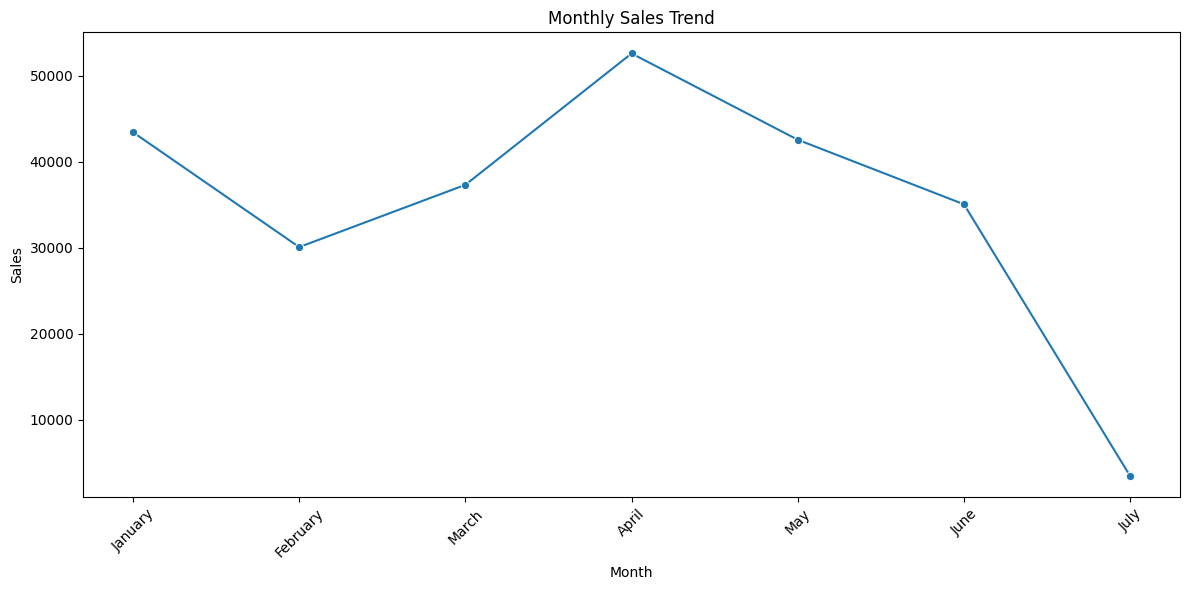

In [21]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_summary, x="Month", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 22. Customer Satisfaction Analysis

In [22]:
rating_summary = df.groupby("Rating Segment", observed=True).agg(
    Transactions=("Invoice ID", "count"),
    Sales=("Sales", "sum"),
    Average_Rating=("Rating", "mean")
).reset_index()

display(rating_summary)

print("Overall average rating:", round(avg_rating, 2))


,Rating Segment,Transactions,Sales,Average_Rating
0,Average,234,"115,603.02",3.47
1,Good,127,"65,329.93",4.18
2,Excellent,139,"63,478.13",4.72


Overall average rating: 3.99


## 23. Rating by Category

In [23]:
rating_category = df.groupby("Category").agg(
    Average_Rating=("Rating", "mean"),
    Transactions=("Invoice ID", "count"),
    Sales=("Sales", "sum")
).reset_index().sort_values("Average_Rating", ascending=False)

display(rating_category)


,Category,Average_Rating,Transactions,Sales
0,Bakery,4.24,28,"6,516.10"
6,Snacks,4.11,75,"16,992.97"
2,Dairy,4.03,68,"43,992.00"
7,Vegetables,3.99,48,"11,124.17"
1,Beverages,3.96,82,"56,108.24"
5,Personal Care,3.95,73,"45,943.96"
4,Grocery,3.94,82,"40,470.47"
3,Fruits,3.83,44,"23,263.17"


## 24. Correlation Analysis

,Quantity,Unit Price,Rating,Sales
Quantity,1.00,-0.01,0.00,0.57
Unit Price,-0.01,1.00,-0.09,0.72
Rating,0.00,-0.09,1.00,-0.05
Sales,0.57,0.72,-0.05,1.00


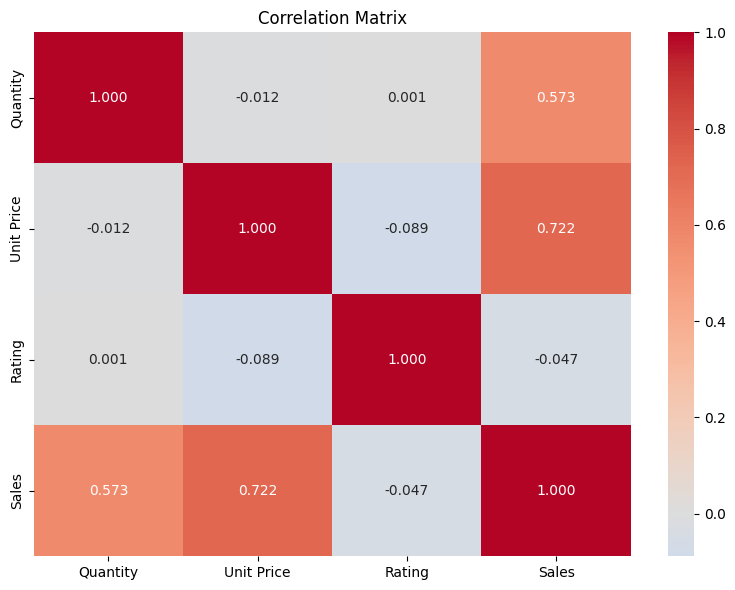

In [24]:
corr_cols = ["Quantity", "Unit Price", "Rating", "Sales"]
corr = df[corr_cols].corr()

display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 25. Quantity vs Sales

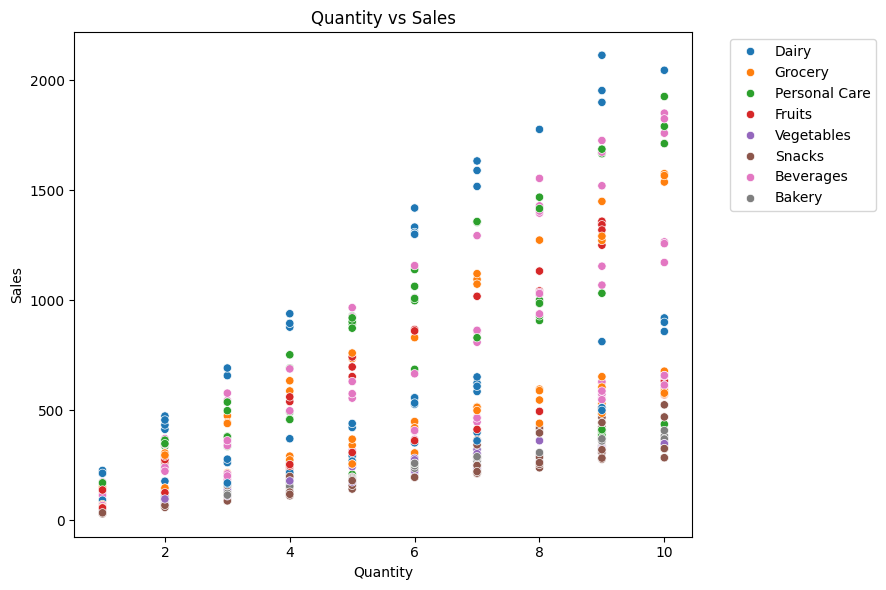

In [25]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Quantity", y="Sales", hue="Category")
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 26. Unit Price vs Sales

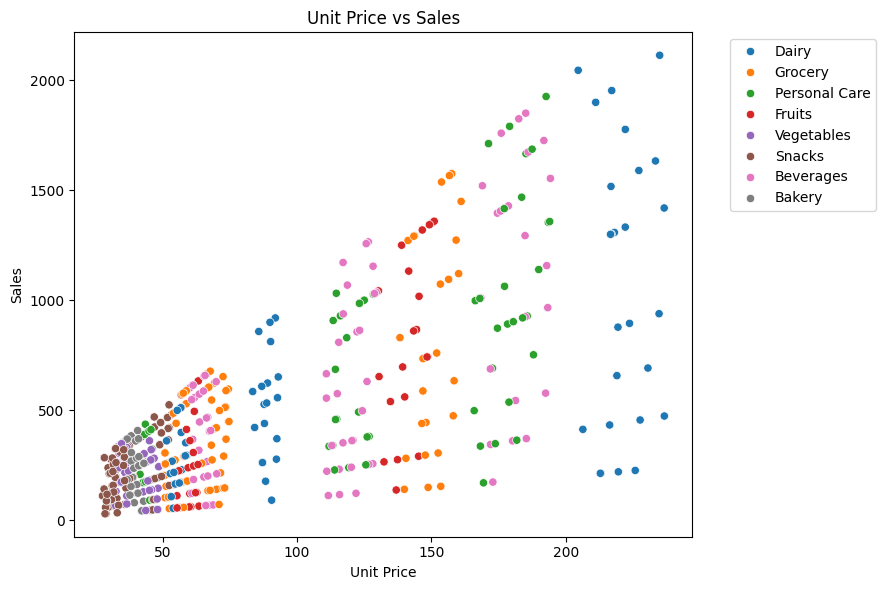

In [26]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Unit Price", y="Sales", hue="Category")
plt.title("Unit Price vs Sales")
plt.xlabel("Unit Price")
plt.ylabel("Sales")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 27. Rating vs Sales

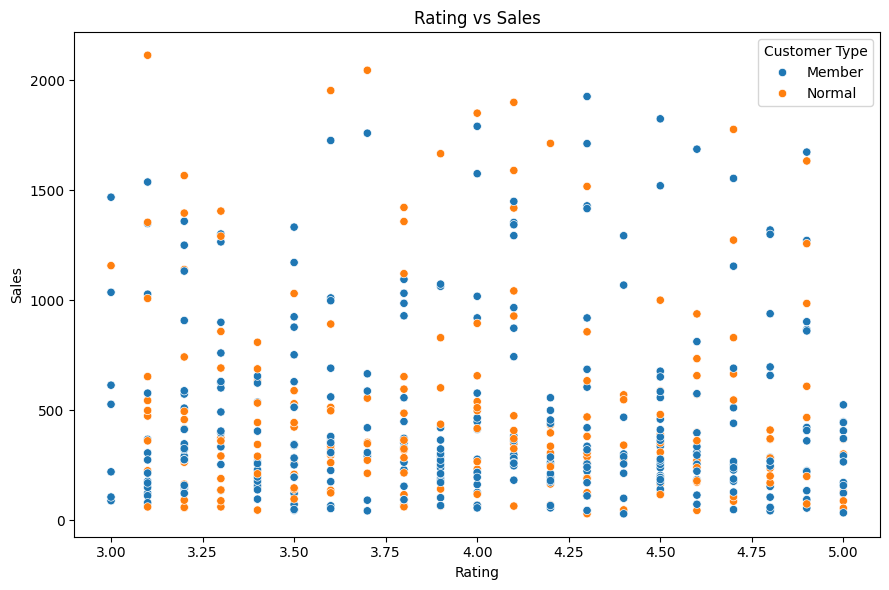

In [27]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Rating", y="Sales", hue="Customer Type")
plt.title("Rating vs Sales")
plt.xlabel("Rating")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


## 28. Branch × Category Analysis

Category,Bakery,Beverages,Dairy,Fruits,Grocery,Personal Care,Snacks,Vegetables
Branch,,,,,,,,
A,"1,860.45","7,934.12","10,674.63","4,986.25","9,277.61","12,119.24","2,994.70","2,510.08"
B,"1,990.01","18,218.06","10,516.22","8,625.88","6,750.82","11,425.62","3,564.92","3,024.73"
C,"1,130.45","11,637.59","16,203.23","7,306.09","13,254.70","15,312.00","4,803.03","2,822.36"
D,"1,535.19","18,318.47","6,597.92","2,344.95","11,187.34","7,087.10","5,630.32","2,767.00"


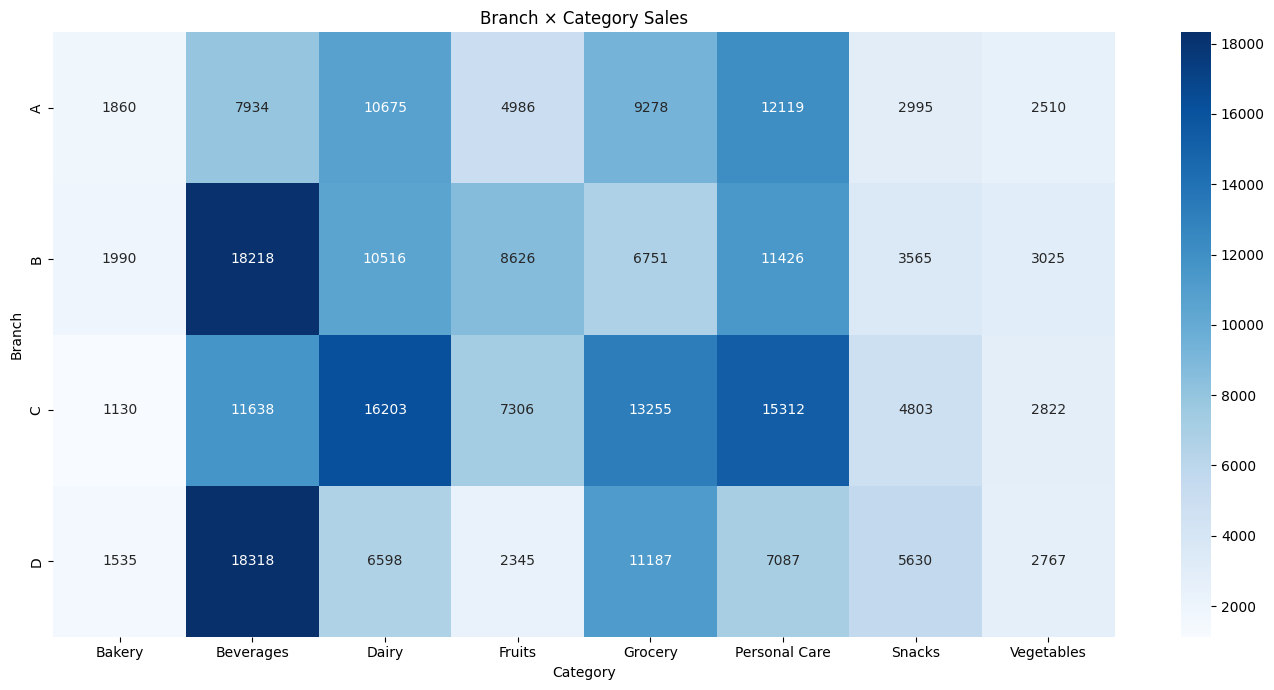

In [28]:
branch_category = pd.pivot_table(
    df,
    values="Sales",
    index="Branch",
    columns="Category",
    aggfunc="sum",
    fill_value=0
)

display(branch_category)

plt.figure(figsize=(14, 7))
sns.heatmap(branch_category, annot=True, fmt=".0f", cmap="Blues")
plt.title("Branch × Category Sales")
plt.xlabel("Category")
plt.ylabel("Branch")
plt.tight_layout()
plt.show()


## 29. Product × Customer Type Analysis

In [29]:
product_customer = pd.pivot_table(
    df,
    values="Sales",
    index="Product",
    columns="Customer Type",
    aggfunc="sum",
    fill_value=0
)

display(product_customer)

product_customer["Total Sales"] = product_customer.sum(axis=1)
product_customer["Member Share %"] = (
    product_customer.get("Member", 0) / product_customer["Total Sales"] * 100
)

display(product_customer.sort_values("Total Sales", ascending=False).head(10))


Customer Type,Member,Normal
Product,,
Apples,"13,652.98","3,404.43"
Bananas,"2,810.29","3,395.47"
Biscuits,"2,234.16","1,674.71"
Bread,"4,247.49","2,268.61"
Cheese,"8,587.12","19,319.18"
Chips,"3,893.91","1,939.54"
Chocolate,"2,938.29","4,312.36"
Coffee,"16,810.43","10,884.44"
Cold Drink,"7,762.41","2,969.37"


Customer Type,Member,Normal,Total Sales,Member Share %
Product,,,,
Cheese,"8,587.12","19,319.18","27,906.30",30.77
Coffee,"16,810.43","10,884.44","27,694.87",60.70
Shampoo,"17,770.07","9,727.41","27,497.48",64.62
Cooking Oil,"12,121.10","9,403.96","21,525.06",56.31
Tea,"10,251.57","7,430.02","17,681.59",57.98
Apples,"13,652.98","3,404.43","17,057.41",80.04
Face Wash,"7,714.17","4,232.68","11,946.85",64.57
Rice,"5,072.55","6,681.62","11,754.17",43.16
Cold Drink,"7,762.41","2,969.37","10,731.78",72.33


## 30. Product Performance Matrix

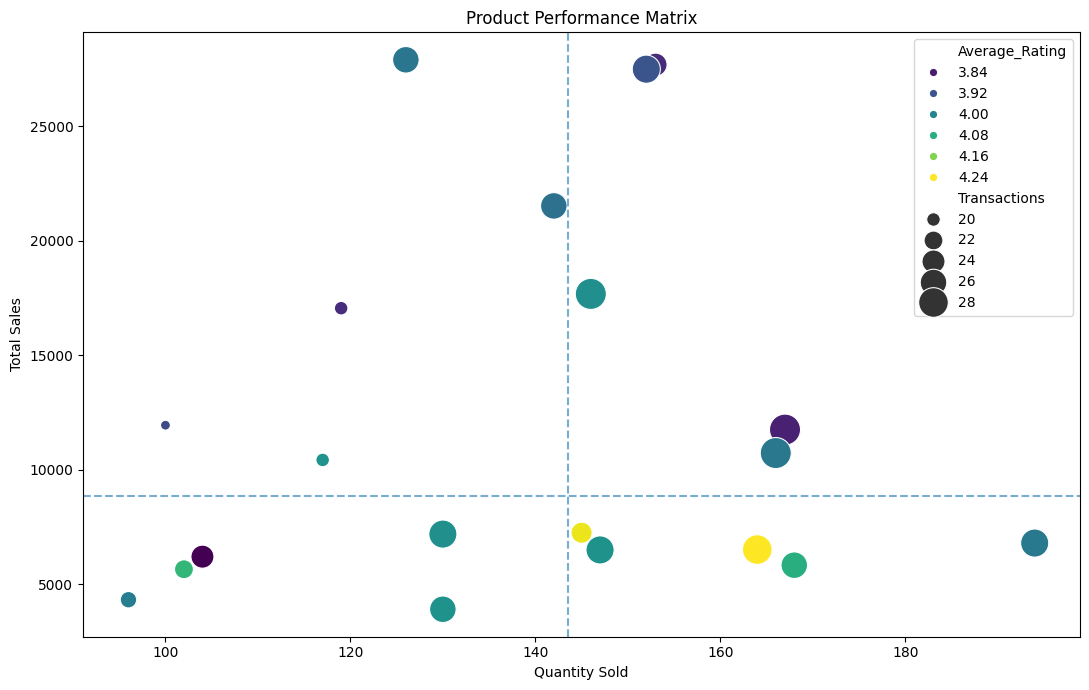

In [30]:
matrix = product_summary.copy()

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=matrix,
    x="Quantity",
    y="Sales",
    size="Transactions",
    hue="Average_Rating",
    sizes=(50, 500),
    palette="viridis"
)

plt.axvline(matrix["Quantity"].median(), linestyle="--", alpha=0.6)
plt.axhline(matrix["Sales"].median(), linestyle="--", alpha=0.6)

plt.title("Product Performance Matrix")
plt.xlabel("Quantity Sold")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


## 31. Outlier Analysis Using IQR

In [31]:
def iqr_outliers(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (dataframe[column] < lower) | (dataframe[column] > upper)
    return dataframe[mask], lower, upper

outlier_results = {}

for col in ["Quantity", "Unit Price", "Sales", "Rating"]:
    outliers, lower, upper = iqr_outliers(df, col)
    outlier_results[col] = {
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": len(outliers)
    }

display(pd.DataFrame(outlier_results).T)

for col in ["Quantity", "Unit Price", "Sales", "Rating"]:
    outliers, lower, upper = iqr_outliers(df, col)
    print(f"\n{col}: {len(outliers)} outliers")
    if len(outliers):
        display(outliers[["Invoice ID", "Product", "Category", "Quantity", "Unit Price", "Sales", "Rating"]].head(20))


,Lower Bound,Upper Bound,Outlier Count
Quantity,-4.50,15.50,0.00
Unit Price,-82.96,255.49,0.00
Sales,-441.80,"1,240.89",51.00
Rating,2.00,6.00,0.00



Quantity: 0 outliers

Unit Price: 0 outliers

Sales: 51 outliers


,Invoice ID,Product,Category,Quantity,Unit Price,Sales,Rating
12,INV0013,Shampoo,Personal Care,9,185.23,"1,667.07",3.90
21,INV0022,Coffee,Beverages,8,177.80,"1,422.40",3.80
28,INV0029,Shampoo,Personal Care,10,192.72,"1,927.20",4.30
44,INV0045,Cheese,Dairy,9,234.98,"2,114.82",3.10
82,INV0083,Cooking Oil,Grocery,9,143.76,"1,293.84",4.40
86,INV0087,Apples,Fruits,9,149.92,"1,349.28",3.10
91,INV0092,Shampoo,Personal Care,7,193.54,"1,354.78",3.10
95,INV0096,Cheese,Dairy,7,227.23,"1,590.61",4.10
115,INV0116,Apples,Fruits,9,150.47,"1,354.23",4.10
119,INV0120,Apples,Fruits,9,138.96,"1,250.64",3.20



Rating: 0 outliers


## 32. Statistical Test — Member vs Normal Sales

In [32]:
# Welch's t-test is used because it does not require equal variances.
member_sales = df.loc[df["Customer Type"].eq("Member"), "Sales"]
normal_sales = df.loc[df["Customer Type"].eq("Normal"), "Sales"]

t_stat, p_value = stats.ttest_ind(member_sales, normal_sales, equal_var=False)

stat_test = pd.DataFrame({
    "Test": ["Welch's independent samples t-test"],
    "Statistic": [t_stat],
    "P-value": [p_value]
})

display(stat_test)

print("Null hypothesis (H0): Mean transaction sales are equal between Member and Normal customers.")
print("Alternative hypothesis (H1): Mean transaction sales differ between Member and Normal customers.")
print("Interpretation should use the chosen significance level and should not be treated as causal evidence.")


,Test,Statistic,P-value
0,Welch's independent samples t-test,-0.35,0.73


Null hypothesis (H0): Mean transaction sales are equal between Member and Normal customers.
Alternative hypothesis (H1): Mean transaction sales differ between Member and Normal customers.
Interpretation should use the chosen significance level and should not be treated as causal evidence.


## 33. ANOVA — Sales Across Categories

In [33]:
category_groups = [
    group["Sales"].values
    for _, group in df.groupby("Category")
]

anova_stat, anova_p = stats.f_oneway(*category_groups)

anova_result = pd.DataFrame({
    "Test": ["One-way ANOVA"],
    "Statistic": [anova_stat],
    "P-value": [anova_p]
})

display(anova_result)

print("H0: Mean sales are equal across categories.")
print("H1: At least one category has a different mean sales value.")


,Test,Statistic,P-value
0,One-way ANOVA,14.70,0.00


H0: Mean sales are equal across categories.
H1: At least one category has a different mean sales value.


## 34. Chi-Square Test — Customer Type vs Payment

In [34]:
contingency = pd.crosstab(df["Customer Type"], df["Payment"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

chi_result = pd.DataFrame({
    "Statistic": [chi2],
    "Degrees of Freedom": [dof],
    "P-value": [p]
})

display(contingency)
display(chi_result)

print("H0: Customer Type and Payment Method are independent.")
print("H1: Customer Type and Payment Method are associated.")


Payment,Card,Cash,Net Banking,UPI
Customer Type,,,,
Member,72,69,76,79
Normal,53,53,50,48


,Statistic,Degrees of Freedom,P-value
0,1.03,3,0.80


H0: Customer Type and Payment Method are independent.
H1: Customer Type and Payment Method are associated.


## 35. Customer Type × Category

In [35]:
customer_category = df.groupby(["Customer Type", "Category"]).agg(
    Transactions=("Invoice ID", "count"),
    Sales=("Sales", "sum"),
    Quantity=("Quantity", "sum"),
    Average_Rating=("Rating", "mean")
).reset_index()

display(customer_category.sort_values("Sales", ascending=False))


,Customer Type,Category,Transactions,Sales,Quantity,Average_Rating
1,Member,Beverages,49,"34,824.41",296,4.01
5,Member,Personal Care,43,"29,115.42",247,3.95
10,Normal,Dairy,30,"24,259.20",157,3.95
4,Member,Grocery,47,"22,043.06",239,3.94
9,Normal,Beverages,33,"21,283.83",169,3.88
2,Member,Dairy,38,"19,732.80",188,4.10
12,Normal,Grocery,35,"18,427.41",200,3.94
13,Normal,Personal Care,30,"16,828.54",152,3.96
3,Member,Fruits,25,"16,463.27",141,3.94
6,Member,Snacks,42,"9,066.36",244,4.17


## 36. Top Business Findings

In [36]:
top_city = city_summary.iloc[0]
top_category = category_summary.iloc[0]
top_product = product_summary.iloc[0]
top_payment = payment_summary.iloc[0]
top_month = monthly_summary.loc[monthly_summary["Sales"].idxmax()]

member_sales = df.loc[df["Customer Type"].eq("Member"), "Sales"].sum()
normal_sales = df.loc[df["Customer Type"].eq("Normal"), "Sales"].sum()

findings = [
    f"Total recorded sales are ₹{total_sales:,.2f} across {transactions:,} transactions.",
    f"{top_city['City']} has the highest recorded city sales at ₹{top_city['Sales']:,.2f}, representing {top_city['Sales Share %']:.2f}% of total sales.",
    f"{top_category['Category']} is the highest-sales category at ₹{top_category['Sales']:,.2f}.",
    f"{top_product['Product']} is the highest-sales product at ₹{top_product['Sales']:,.2f}.",
    f"Member customers account for ₹{member_sales:,.2f}, or {member_sales/total_sales*100:.2f}% of sales.",
    f"{top_payment['Payment']} has the highest recorded payment-method sales at ₹{top_payment['Sales']:,.2f}.",
    f"{top_month['Month']} {int(top_month['Year'])} has the highest monthly sales in the supplied records at ₹{top_month['Sales']:,.2f}.",
    f"The overall average customer rating is {avg_rating:.2f}/5."
]

for i, finding in enumerate(findings, 1):
    print(f"{i}. {finding}")


1. Total recorded sales are ₹244,411.08 across 500 transactions.
2. Mumbai has the highest recorded city sales at ₹72,469.45, representing 29.65% of total sales.
3. Beverages is the highest-sales category at ₹56,108.24.
4. Cheese is the highest-sales product at ₹27,906.30.
5. Member customers account for ₹143,009.30, or 58.51% of sales.
6. UPI has the highest recorded payment-method sales at ₹67,910.33.
7. April 2026 has the highest monthly sales in the supplied records at ₹52,569.77.
8. The overall average customer rating is 3.99/5.


## 37. Business Recommendations

Recommendations should be based only on observed data.

### Suggested analytical actions

1. Monitor high-sales products and categories for availability and demand continuity.
2. Compare branch/category performance regularly to identify changing sales patterns.
3. Monitor Member customer purchasing behavior separately from Normal customers.
4. Track payment-channel usage to support convenient payment options.
5. Monitor rating trends by product and category to identify customer-experience areas for review.
6. Avoid interpreting sales as profit until cost and expense data are available.
7. Continue collecting data across complete months and a longer period before making seasonal conclusions.
8. Add cost, inventory, promotion, customer demographic and margin data in future versions for deeper analysis.


## 38. Dashboard-Ready Tables

In [37]:
# Export clean analytical tables for use in Excel / Power BI / IBM Bob / other BI tools.

output_dir = Path("supermarket_analytics_outputs")
output_dir.mkdir(exist_ok=True)

df.to_csv(output_dir / "clean_supermarket_data.csv", index=False)
city_summary.to_csv(output_dir / "city_summary.csv", index=False)
branch_summary.to_csv(output_dir / "branch_summary.csv", index=False)
product_summary.to_csv(output_dir / "product_summary.csv", index=False)
category_summary.to_csv(output_dir / "category_summary.csv", index=False)
customer_summary.to_csv(output_dir / "customer_type_summary.csv", index=False)
gender_summary.to_csv(output_dir / "gender_summary.csv", index=False)
payment_summary.to_csv(output_dir / "payment_summary.csv", index=False)
monthly_summary.to_csv(output_dir / "monthly_summary.csv", index=False)
rating_category.to_csv(output_dir / "rating_category_summary.csv", index=False)
branch_category.to_csv(output_dir / "branch_category_sales.csv")

print(f"Analytics outputs saved to: {output_dir.resolve()}")


Analytics outputs saved to: /content/supermarket_analytics_outputs


## 39. Final Project Conclusion

### Project outcome

This project transforms raw supermarket transaction data into a structured retail analytics solution covering:

- Revenue KPIs
- Geographic performance
- Product and category performance
- Customer segmentation
- Payment behavior
- Customer satisfaction
- Time-series analysis
- Correlation analysis
- Outlier detection
- Statistical testing
- Cross-segment analysis
- Business insights and recommendations

### Data limitations

The dataset contains only 500 transactions and covers January–July 2026. July is incomplete in the supplied records. The dataset also lacks cost, profit, inventory, discount, promotion and detailed customer demographic information.

Therefore, conclusions should be interpreted as **descriptive findings from the supplied transaction data**, not as a complete measure of supermarket profitability or long-term market behavior.
